![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [1]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
# !pip install -r requirements.txt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics
%matplotlib inline

In [4]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [5]:
df.shape

(541462, 3)

<Axes: >

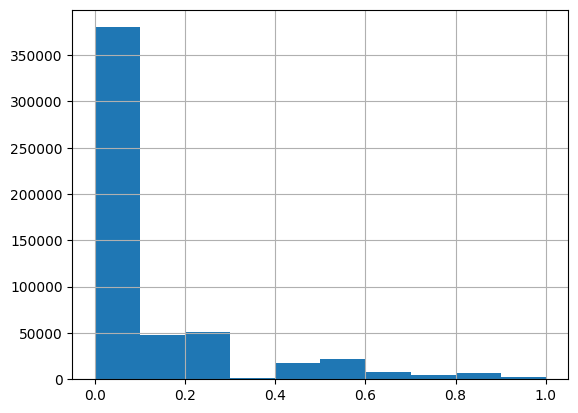

In [6]:
# Impresión histograma de variable de interés (y)
df.target.hist()

In [7]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [8]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [9]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [10]:
# Celda 1 - Tokenización con CountVectorizer

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# 1. Crear vectorizador
count_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000
)

# 2. Ajustar SOLO con entrenamiento y transformar train
X_train_count = count_vectorizer.fit_transform(X_train)

# 3. Transformar test con el mismo vectorizador
X_test_count = count_vectorizer.transform(X_test)

# 4. Modelo de regresión
modelo_count = Ridge(alpha=1.0)

# 5. Entrenamiento
modelo_count.fit(X_train_count, y_train)

# 6. Predicciones
y_pred_count = modelo_count.predict(X_test_count)

# 7. Limitar predicciones entre 0 y 1
y_pred_count = np.clip(y_pred_count, 0, 1)

# 8. Evaluación MSE
mse_count = mean_squared_error(y_test, y_pred_count)

print("MSE CountVectorizer + Ridge:", mse_count)

MSE CountVectorizer + Ridge: 0.023445671427126995


## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [11]:
# Celda 2 - Tokenización con CountVectorizer y trigramas

# 1. Crear vectorizador con trigramas
count_vectorizer_tri = CountVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(3, 3),
    max_features=5000
)

# 2. Ajustar SOLO con entrenamiento
X_train_tri = count_vectorizer_tri.fit_transform(X_train)

# 3. Transformar test con el mismo vectorizador
X_test_tri = count_vectorizer_tri.transform(X_test)

# 4. Usar el mismo modelo del punto anterior
modelo_tri = Ridge(alpha=1.0)

# 5. Entrenar modelo
modelo_tri.fit(X_train_tri, y_train)

# 6. Predecir
y_pred_tri = modelo_tri.predict(X_test_tri)

# 7. Limitar predicciones entre 0 y 1
y_pred_tri = np.clip(y_pred_tri, 0, 1)

# 8. Evaluar con MSE
mse_tri = mean_squared_error(y_test, y_pred_tri)

print("MSE CountVectorizer con trigramas + Ridge:", mse_tri)

MSE CountVectorizer con trigramas + Ridge: 0.03863533794124468


## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o desventajas de su uso al compararlo con la función CountVectorizer.

#Celda 3
El TfidfVectorizer es una técnica de procesamiento de texto que permite convertir palabras en valores numéricos, pero no solo contando cuántas veces aparece cada palabra (como hace CountVectorizer), sino teniendo en cuenta qué tan importante es dentro de todos los documentos.

Esta técnica se basa en dos componentes. El primero es la frecuencia del término (TF), que mide cuántas veces aparece una palabra en un texto. El segundo es la frecuencia inversa de documento (IDF), que reduce el peso de las palabras que aparecen muy frecuentemente en todos los textos. De esta forma, palabras comunes como “the” o “and” tienen menos importancia, mientras que palabras más específicas tienen mayor peso.

El funcionamiento de TF-IDF consiste en darle mayor valor a las palabras que aparecen varias veces en un documento, pero que no son tan comunes en el resto del conjunto de datos. Esto ayuda a que el modelo se enfoque en palabras más relevantes.

En comparación con CountVectorizer, TF-IDF tiene varias ventajas. Por ejemplo, reduce el impacto de palabras muy comunes, mejora la calidad de los modelos y permite capturar mejor la relevancia de las palabras en el texto. Sin embargo, también tiene algunas desventajas, como un mayor costo computacional y que los valores pueden ser menos intuitivos que los simples conteos.

En conclusión, TF-IDF es una mejora frente a CountVectorizer porque no solo cuenta palabras, sino que también considera su importancia, lo que suele generar mejores resultados en tareas de procesamiento de lenguaje natural.

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [12]:
# Celda 4

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Crear vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000
)

# 2. Ajustar SOLO con entrenamiento
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# 3. Transformar test
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# 4. Usar mismo modelo
modelo_tfidf = Ridge(alpha=1.0)

# 5. Entrenar
modelo_tfidf.fit(X_train_tfidf, y_train)

# 6. Predecir
y_pred_tfidf = modelo_tfidf.predict(X_test_tfidf)

# 7. Limitar entre 0 y 1
y_pred_tfidf = np.clip(y_pred_tfidf, 0, 1)

# 8. Evaluar
mse_tfidf = mean_squared_error(y_test, y_pred_tfidf)

print("MSE TF-IDF + Ridge:", mse_tfidf)

MSE TF-IDF + Ridge: 0.02020696437912615


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

                      Modelo       MSE
0            CountVectorizer  0.023446
1  CountVectorizer Trigramas  0.038635
2                     TF-IDF  0.020207


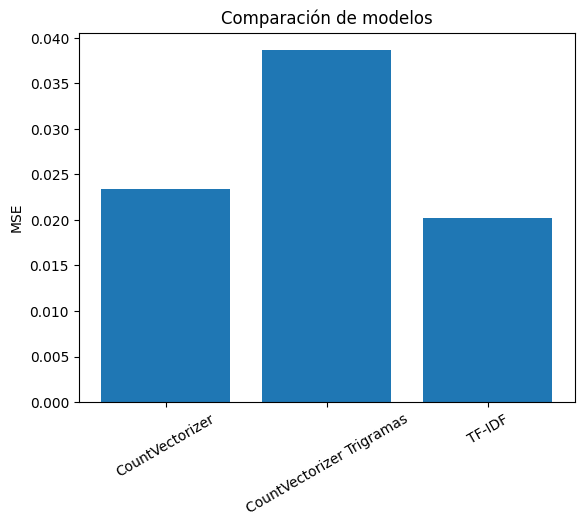

In [13]:
# Celda 5 Código para graficos y tablas comparativas

import pandas as pd
import matplotlib.pyplot as plt

# Crear tabla comparativa
resultados = pd.DataFrame({
    "Modelo": ["CountVectorizer", "CountVectorizer Trigramas", "TF-IDF"],
    "MSE": [mse_count, mse_tri, mse_tfidf]
})

print(resultados)

# Gráfico
plt.figure()
plt.bar(resultados["Modelo"], resultados["MSE"])
plt.xticks(rotation=30)
plt.title("Comparación de modelos")
plt.ylabel("MSE")
plt.show()

### Punto 5.1 - Comparación y análisis de resultados
Al comparar los modelos, se observa que el modelo con TF-IDF presenta el mejor desempeño, obteniendo el menor MSE (0.0202), seguido por el modelo con CountVectorizer básico (0.0234), mientras que el modelo con trigramas tiene el peor desempeño (0.0386).

El modelo con CountVectorizer básico logra un resultado adecuado, ya que considera la frecuencia de las palabras individuales, capturando información relevante del texto. Sin embargo, no diferencia entre palabras comunes y palabras importantes dentro del corpus.

Por otro lado, el modelo con trigramas, aunque permite capturar mayor contexto al considerar combinaciones de tres palabras, genera una representación mucho más dispersa del texto. Esto incrementa la dimensionalidad del modelo y puede dificultar el aprendizaje, lo que se refleja en un mayor error (MSE).

Finalmente, el modelo con TF-IDF obtiene el mejor resultado debido a que pondera las palabras según su relevancia en el conjunto de datos, reduciendo el peso de palabras comunes y resaltando aquellas más informativas. Esto permite mejorar la capacidad del modelo para identificar patrones asociados a la toxicidad.

En conclusión, el preprocesamiento del texto tiene un impacto significativo en el desempeño del modelo, siendo TF-IDF la mejor alternativa en este caso, ya que logra un mejor balance entre representación de la información y capacidad predictiva.